# 02 — Dataset Analysis (EDA)

Explore the standardized dataset to understand its size, class balance, generator distribution, and visual characteristics.

## Load dataset

Read data/dataset.csv created in the preparation notebook.

In [1]:
import sys
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

def find_repo_root(start: Path) -> Path:
    """Find the repository root from the current working directory."""
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config, raw_data_root

config: dict = load_config()

SEED: int = config["seed"]
GENERATORS: list[str] = config["generators"]

RAW_ROOT: Path = raw_data_root(config)
PROCESSED_ROOT: Path = REPO_ROOT / "data" / "processed"
FIGURES_ROOT: Path = REPO_ROOT / "results" / "figures"
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

dataset_path: Path = REPO_ROOT / "data" / "dataset.csv"
dataset: pd.DataFrame = pd.read_csv(dataset_path)

print(f"Loaded {len(dataset)} rows from {dataset_path.relative_to(REPO_ROOT)}")
print(f"columns: {list(dataset.columns)}\n")
dataset.head()

Loaded 14000 rows from data\dataset.csv
columns: ['filename', 'label', 'generator', 'source_group', 'raw_split', 'split', 'source_path']



,filename,label,generator,source_group,raw_split,split,source_path
0,ai/biggan__655_biggan_00054.jpg,ai,biggan,biggan,train,train,imagenet_ai_0419_biggan/train/ai/655_biggan_00...
1,ai/biggan__120_biggan_00118.jpg,ai,biggan,biggan,train,train,imagenet_ai_0419_biggan/train/ai/120_biggan_00...
2,ai/biggan__026_biggan_00175.jpg,ai,biggan,biggan,train,train,imagenet_ai_0419_biggan/train/ai/026_biggan_00...
3,ai/biggan__757_biggan_00140.jpg,ai,biggan,biggan,train,train,imagenet_ai_0419_biggan/train/ai/757_biggan_00...
4,ai/biggan__298_biggan_00179.jpg,ai,biggan,biggan,train,train,imagenet_ai_0419_biggan/train/ai/298_biggan_00...


## Class balance

Check the distribution of real and AI images overall and across the dataset splits.

Label balance overall:
label
ai      7000
real    7000
Name: count, dtype: int64 

Label balance per split:
label    ai  real
split            
test   1050  1050
train  4900  4900
val    1050  1050 



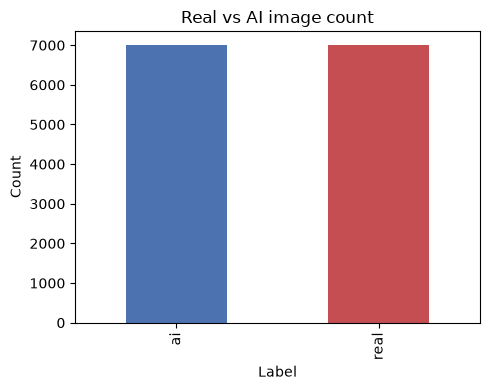

In [2]:
print("Label balance overall:")
print(dataset["label"].value_counts(), "\n")

print("Label balance per split:")
balance_by_split: pd.DataFrame = dataset.groupby(["split", "label"]).size().unstack()
print(balance_by_split, "\n")

fig, ax = plt.subplots(figsize=(5, 4))
dataset["label"].value_counts().plot(kind="bar", ax=ax, color=["#4c72b0", "#c44e52"])
ax.set_title("Real vs AI image count")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "class_balance.png", dpi=150)
plt.show()

label_counts = dataset["label"].value_counts()
assert label_counts["ai"] == label_counts["real"], (
    f"AI/real counts diverged ({label_counts['ai']} vs {label_counts['real']})"
)

## Per-generator distribution

Check the number of AI-generated images available for each generator.

AI images per generator:
generator
biggan        1000
glide         1000
vqdm          1000
sdv1_5        1000
adm           1000
midjourney    1000
wukong        1000
Name: count, dtype: int64 



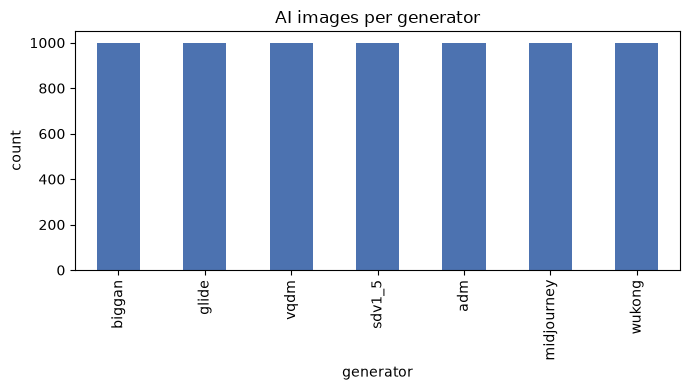

In [3]:
print("AI images per generator:")
generator_counts: pd.Series = dataset[dataset.label == "ai"]["generator"].value_counts().reindex(GENERATORS)
print(generator_counts, "\n")

fig, ax = plt.subplots(figsize=(7, 4))
generator_counts.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_title("AI images per generator")
ax.set_xlabel("generator")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "generator_distribution.png", dpi=150)
plt.show()

# All generators should have the same number of AI images.
assert generator_counts.nunique() == 1, f"generator counts aren't equal: {generator_counts.to_dict()}"

## Split distribution

Check how images from each source are distributed across the train, validation, and test sets.

split       test  train   val
generator                    
biggan       150    700   150
glide        150    700   150
vqdm         150    700   150
sdv1_5       150    700   150
adm          150    700   150
midjourney   150    700   150
wukong       150    700   150
real        1050   4900  1050 



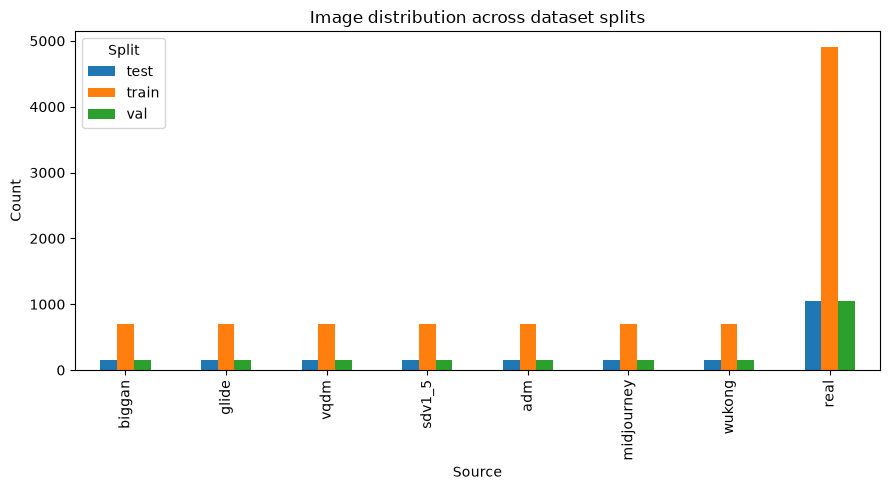

Split ratios:
split       test  train   val
generator                    
biggan      0.15    0.7  0.15
glide       0.15    0.7  0.15
vqdm        0.15    0.7  0.15
sdv1_5      0.15    0.7  0.15
adm         0.15    0.7  0.15
midjourney  0.15    0.7  0.15
wukong      0.15    0.7  0.15
real        0.15    0.7  0.15 



In [4]:
split_distribution: pd.DataFrame = (
    dataset.groupby(["generator", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(GENERATORS + ["real"])
)
print(split_distribution, "\n")


fig, ax = plt.subplots(figsize=(9, 5))
split_distribution.plot(kind="bar", ax=ax)
ax.set_title("Image distribution across dataset splits")
ax.set_xlabel("Source")
ax.set_ylabel("Count")
ax.legend(title="Split")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "split_distribution.png", dpi=150)
plt.show()

expected_train = config["standard_split"]["train"]
expected_val = config["standard_split"]["val"]
expected_test = config["standard_split"]["test"]

# Derived from split_distribution directly (row-wise divide by row totals)
# rather than a second groupby().apply() -- that pattern re-adds "generator"
# as an extra index level in the output, which is just noise here.
split_ratios: pd.DataFrame = split_distribution.div(split_distribution.sum(axis=1), axis=0)
print("Split ratios:")
print(split_ratios, "\n")

## Original image properties

Check the original image sizes and formats before standardization.
This helps verify the preprocessing applied in notebook 01.

In [5]:
def get_image_properties(path: str) -> tuple[tuple[int, int], str]:
    """Return the original image size and format.

    Args:
        path: Path to the source image.

    Returns:
        A tuple containing the image size as (width, height) and its format.
    """
    with Image.open(RAW_ROOT / path) as img:
        return img.size, img.format

SAMPLE_PER_SOURCE = 50

image_properties: list[dict] = []
for source, group in dataset.groupby("generator"):
    sample = group.sample(min(SAMPLE_PER_SOURCE, len(group)), random_state=SEED)
    for path in sample["source_path"]:
        (width, height), fmt = get_image_properties(path)
        image_properties.append({"generator": source, "width": width, "height": height, "format": fmt})

properties_df = pd.DataFrame(image_properties)
properties_df["size"] = list(zip(properties_df["width"], properties_df["height"]))

summary: pd.DataFrame = properties_df.groupby("generator").agg(
    n_unique_sizes=("size", "nunique"),
    width_min=("width", "min"),
    width_max=("width", "max"),
    height_min=("height", "min"),
    height_max=("height", "max"),
    formats=("format", lambda x: sorted(set(x))),
)
print(summary, "\n")

prep = config["preprocessing"]
print(
    f"Standardized target: "
    f"{prep['image_size']}x{prep['image_size']} {prep['color_mode']}, "
    f"JPEG quality={prep['jpeg_quality']}"
)

            n_unique_sizes  width_min  width_max  height_min  height_max  \
generator                                                                  
adm                      1        256        256         256         256   
biggan                   1        128        128         128         128   
glide                    1        256        256         256         256   
midjourney               1       1024       1024        1024        1024   
real                    27         90       2272          90        1704   
sdv1_5                   1        512        512         512         512   
vqdm                     1        256        256         256         256   
wukong                   1        512        512         512         512   

           formats  
generator           
adm          [PNG]  
biggan       [PNG]  
glide        [PNG]  
midjourney   [PNG]  
real        [JPEG]  
sdv1_5       [PNG]  
vqdm         [PNG]  
wukong       [PNG]   

Standardized target: 224x22

## Sample image grids

Visually inspect a random sample of standardized images from each source.

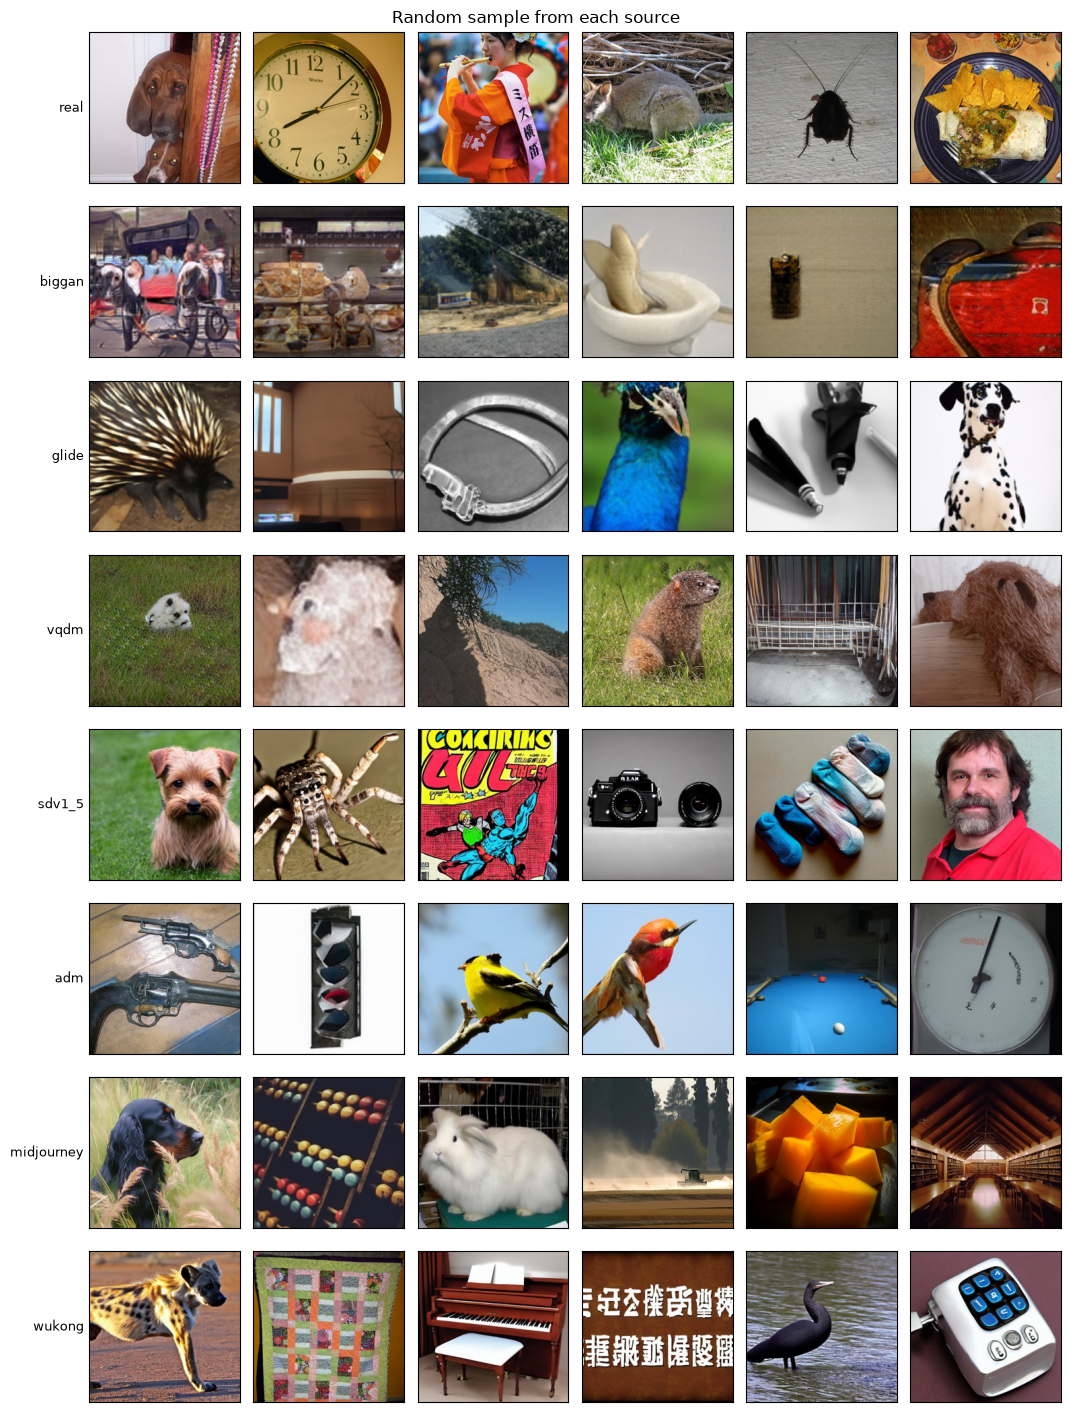

In [6]:
SOURCES: list[str] = ["real"] + GENERATORS 
N_COLS = 6
rng = random.Random(SEED)

fig, axes = plt.subplots(len(SOURCES), N_COLS, figsize=(N_COLS * 1.8, len(SOURCES) * 1.8))
for row, source in enumerate(SOURCES):
    pool: list[str] = dataset[dataset["generator"] == source]["filename"].tolist()
    sample: list[str] = rng.sample(pool, N_COLS)
    for col, filename in enumerate(sample):
        ax = axes[row, col]
        ax.imshow(Image.open(PROCESSED_ROOT / filename))
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(source, rotation=0, ha="right", va="center", fontsize=9)

fig.suptitle("Random sample from each source")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "sample_grid.png", dpi=150)
plt.show()

## Duplicate check

Check for exact duplicate images within and across sources.

In [7]:
def file_hash(path: Path) -> str:
    """Return the MD5 hash of a standardized image file.

    Args:
        path: Path to the standardized image.

    Returns:
        MD5 hash of the file contents.
    """
    return hashlib.md5(path.read_bytes()).hexdigest()


hashes: dict[str, list[str]] = {}
for filename in dataset["filename"]:
    image_hash = file_hash(PROCESSED_ROOT / filename)
    hashes.setdefault(image_hash, []).append(filename)

duplicate_groups: dict[str, list[str]] = {image_hash: files for image_hash, files in hashes.items() if len(files) > 1}
duplicate_files = sum(len(files) for files in duplicate_groups.values())

print(f"{len(hashes)} unique hashes over {len(dataset)} standardized images")
print(f"Exact duplicates: {duplicate_files} files across {len(duplicate_groups)} groups\n")
for image_hash, files in list(duplicate_groups.items())[:10]:
    print(" ", files)

14000 unique hashes over 14000 standardized images
Exact duplicates: 0 files across 0 groups



## Cross-source perceptual duplicate check

Check whether visually similar images appear across different sources.
This helps identify potential data leakage between generators and dataset splits.

In [8]:
def calculate_perceptual_hash(path: Path) -> imagehash.ImageHash:
    """Calculate a perceptual hash for an image.

    Args:
        path: Path to the image.

    Returns:
        Perceptual hash representing the visual content of the image.
    """
    with Image.open(path) as image:
        return imagehash.phash(image)

SAMPLE_PER_SOURCE_DUPLICATE = 100

hash_records: list[dict] = []
for source, group in dataset.groupby("generator"):
    sample = group.sample(
        min(SAMPLE_PER_SOURCE_DUPLICATE, len(group)),
        random_state=SEED,
    )

    for filename in sample["filename"]:
        hash_records.append(
            {
                "filename": filename,
                "generator": source,
                "hash": calculate_perceptual_hash(PROCESSED_ROOT / filename)
            }
        )

hash_df: pd.DataFrame = pd.DataFrame(hash_records)
print(f"Calculated perceptual hashes for {len(hash_df)} images.")

SIMILARITY_THRESHOLD = 5

# Pairwise Hamming distance
# Convert perceptual hashes into binary arrays for efficient comparison.
bits: np.ndarray = np.stack([h.hash.flatten() for h in hash_df["hash"]]).astype(np.int8)
bit_counts: np.ndarray = bits.sum(axis=1)
overlap: np.ndarray = bits @ bits.T
distance_matrix: np.ndarray = bit_counts[:, None] + bit_counts[None, :] - 2 * overlap

generators: np.ndarray = hash_df["generator"].to_numpy()
filenames: np.ndarray = hash_df["filename"].to_numpy()

# Compare each pair only once and keep pairs from different sources.
i_idx, j_idx = np.triu_indices(len(hash_df), k=1)
keep: np.ndarray = (generators[i_idx] != generators[j_idx]) & (distance_matrix[i_idx, j_idx] <= SIMILARITY_THRESHOLD)

similar_pairs_df = pd.DataFrame(
    {
        "first_file": filenames[i_idx[keep]],
        "first_source": generators[i_idx[keep]],
        "second_file": filenames[j_idx[keep]],
        "second_source": generators[j_idx[keep]],
        "distance": distance_matrix[i_idx, j_idx][keep],
    }
)

print(f"Found {len(similar_pairs_df)} potential cross-source similar pairs.")

similar_pairs_df.head(20)

Calculated perceptual hashes for 800 images.
Found 0 potential cross-source similar pairs.


,first_file,first_source,second_file,second_source,distance


## Image statistics by source

Compare basic color, brightness, and sharpness statistics across sources.

                mean_r      mean_g      mean_b  mean_brightness    sharpness
generator                                                                   
adm         123.883049  120.559525  107.815956       117.419502  1004.245850
biggan      127.253563  122.919601  107.480186       119.217781   153.155792
glide       134.196976  130.631882  115.793846       126.874237   188.763580
midjourney  122.509857  114.806252  102.970367       113.428825  1232.208862
real        123.158340  118.670891  104.157715       115.328987  1575.236572
sdv1_5      119.594002  111.778473   97.193016       109.521835  1979.143311
vqdm        120.753029  109.437889   96.392685       108.861198  1130.659058
wukong      124.158630  116.742699  104.407516       115.102951  2731.720703 



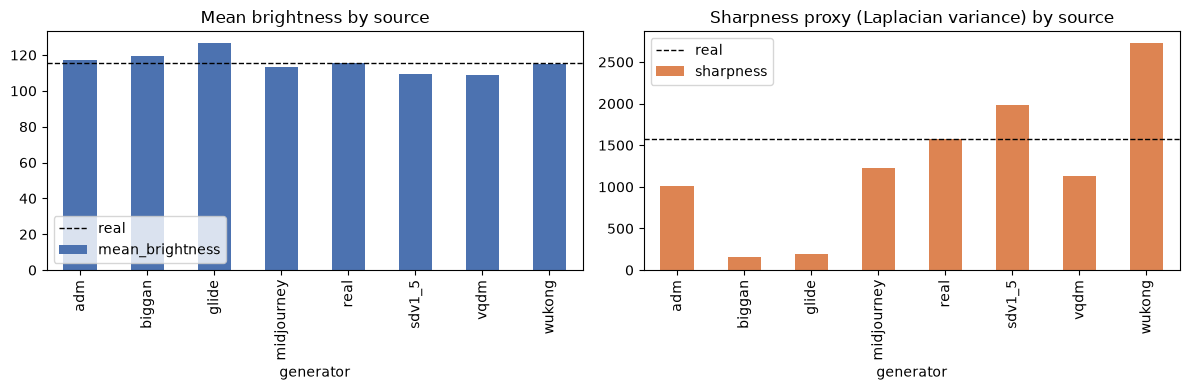

In [9]:
def calculate_image_stats(filename: str) -> dict[str, float]:
    """Calculate basic color, brightness, and sharpness statistics.

    Args:
        filename: Relative path to a standardized image.

    Returns:
        Dictionary containing mean RGB values, mean brightness,
        and a Laplacian-based sharpness measure.
    """
    image = Image.open(PROCESSED_ROOT / filename)
    array = np.asarray(image, dtype=np.float32)

    grayscale = array.mean(axis=-1)

    laplacian = (
        -4 * grayscale[1:-1, 1:-1]
        + grayscale[:-2, 1:-1]
        + grayscale[2:, 1:-1]
        + grayscale[1:-1, :-2]
        + grayscale[1:-1, 2:]
    )

    return {
        "mean_r": array[..., 0].mean(),
        "mean_g": array[..., 1].mean(),
        "mean_b": array[..., 2].mean(),
        "mean_brightness": grayscale.mean(),
        "sharpness": laplacian.var(),
    }


SAMPLE_PER_SOURCE_STATS = 100

stat_rows: list[dict] = []
for source, group in dataset.groupby("generator"):
    sample = group.sample(min(SAMPLE_PER_SOURCE_STATS, len(group)), random_state=SEED)
    for filename in sample["filename"]:
        stat_rows.append({"generator": source, **calculate_image_stats(filename)})

stats_df = pd.DataFrame(stat_rows)
stats_summary: pd.DataFrame = stats_df.groupby("generator")[
    ["mean_r", "mean_g", "mean_b", "mean_brightness", "sharpness"]
].mean()
print(stats_summary, "\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats_summary["mean_brightness"].plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].axhline(stats_summary.loc["real", "mean_brightness"], color="black", linestyle="--", linewidth=1, label="real")
axes[0].set_title("Mean brightness by source")
axes[0].legend()

stats_summary["sharpness"].plot(kind="bar", ax=axes[1], color="#dd8452")
axes[1].axhline(stats_summary.loc["real", "sharpness"], color="black", linestyle="--", linewidth=1, label="real")
axes[1].set_title("Sharpness proxy (Laplacian variance) by source")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_ROOT / "generator_color_stats.png", dpi=150)
plt.show()

**Observations**

- Generator(s) that stand out visually:
  Wukong and Stable Diffusion v1.5 show the highest sharpness values,
  while BigGAN and GLIDE show the lowest. The sample grid can be used
  to visually inspect whether these numerical differences correspond
  to noticeable visual patterns.

- Generator(s) closest to real:
  Midjourney and ADM are relatively close to real images in terms of
  sharpness, although their color and brightness statistics still differ.

- Anything that looks like a trivial shortcut (color cast, sharpness, compression artifacts) rather than genuine generation quality:
  There are noticeable differences in brightness and sharpness between
  generators. In particular, the large sharpness differences suggest that
  low-level image characteristics could provide shortcuts for a classifier.
  Original image format and resolution are also strongly correlated with the
  source, but these were standardized before training to reduce this bias.

- Dataset split:
  All generators and the real class follow the intended 70/15/15
  train/validation/test split, so no major imbalance was introduced
  during dataset preparation.